# Assignment 2

## Task 1

In [4]:
import os, re, json, random
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.sequence import skipgrams

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import pairwise_distances

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

In [5]:
SEED = 14
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR / "train.csv"
TEST_PATH = BASE_DIR / "test.csv"
FRENCH_PATH = BASE_DIR / "french-theater.txt"
GLOVE_PATH = BASE_DIR / "glove.6B.200d.txt"

OUT_DIR = BASE_DIR / "outputs"
OUT_T1 = OUT_DIR / "task1"
OUT_T2 = OUT_DIR / "task2"

(OUT_T1 / "plots").mkdir(parents=True, exist_ok=True)
(OUT_T2 / "plots").mkdir(parents=True, exist_ok=True)

## Task 1 — AG’s News Topic Classification
We use the AG News dataset (4 classes). We first train our own word embeddings on the training split using Skip-gram with Negative Sampling (SGNS). Then we train the same 3-layer recurrent classifier twice:
1) embedding initialized with our SGNS embeddings,
2) embedding initialized with pre-trained GloVe embeddings.

We evaluate on the official test set using accuracy and macro-F1 (macro-F1 is robust to any class imbalance and checks per-class performance).

In [6]:
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH, header=None)

train_df.columns = ["label", "title", "desc"]
test_df.columns  = ["label", "title", "desc"]

# labels 1..4 -> 0..3
train_df["y"] = train_df["label"].astype(int) - 1
test_df["y"]  = test_df["label"].astype(int) - 1

train_df["text"] = (train_df["title"].astype(str) + " " + train_df["desc"].astype(str)).str.strip()
test_df["text"]  = (test_df["title"].astype(str) + " " + test_df["desc"].astype(str)).str.strip()

print(train_df.head())
print("Train size:", len(train_df), "Test size:", len(test_df))
print("Label counts (train):\n", train_df["y"].value_counts().sort_index())

   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                                desc  y  \
0  Reuters - Short-sellers, Wall Street's dwindli...  2   
1  Reuters - Private investment firm Carlyle Grou...  2   
2  Reuters - Soaring crude prices plus worries\ab...  2   
3  Reuters - Authorities have halted oil export\f...  2   
4  AFP - Tearaway world oil prices, toppling reco...  2   

                                                text  
0  Wall St. Bears Claw Back Into the Black (Reute...  
1  Carlyle Looks Toward Commercial Aerospace (Reu...  
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  
3  Iraq Halts Oil Exports from Main Southern P

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"].values,
    train_df["y"].values,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["y"].values
)

X_test = test_df["text"].values
y_test = test_df["y"].values

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 108000 Val: 12000 Test: 7600


In [8]:
MAX_VOCAB = 50000
MAX_LEN = 256  # you can justify via length percentiles if you want

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="[UNK]")
tokenizer.fit_on_texts(X_train)

def texts_to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

x_train = texts_to_padded(X_train)
x_val   = texts_to_padded(X_val)
x_test  = texts_to_padded(X_test)

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index) + 1)  # +1 for padding index
print("Vocab size used:", vocab_size)
print("Example seq:", x_train[0][:20])

Vocab size used: 50000
Example seq: [ 5972 11098 12229   993   188  2673  5049     2   352   604   818    12
    17  8898  2505    19  4582  3568    10    11]


### Task 1.1 — SGNS embeddings trained on AG News training text
We train a Skip-gram model with Negative Sampling on the tokenized AG News training corpus to obtain in-domain word embeddings.

In [9]:
# Create a "corpus" as a list of sequences (already integerized)
# We'll sample skip-gram pairs using Keras helper.
WINDOW_SIZE = 5
NUM_NEG = 5
EMBED_DIM = 200

# Flattened sampling: randomly draw from sequences each step
all_seqs = [s[s != 0] for s in x_train]  # remove padding zeros

def sgns_batch_generator(batch_size=2048):
    rng = np.random.default_rng(SEED)
    while True:
        targets = []
        contexts = []
        labels = []
        # sample sequences and produce pairs until batch filled
        while len(targets) < batch_size:
            seq = all_seqs[rng.integers(0, len(all_seqs))]
            if len(seq) < 2:
                continue
            pairs, pair_labels = skipgrams(
                seq,
                vocabulary_size=vocab_size,
                window_size=WINDOW_SIZE,
                negative_samples=NUM_NEG,
                shuffle=True,
                seed=SEED
            )
            for (t, c), lab in zip(pairs, pair_labels):
                targets.append(t)
                contexts.append(c)
                labels.append(lab)
                if len(targets) >= batch_size:
                    break
        yield (np.array(targets, dtype=np.int32), np.array(contexts, dtype=np.int32)), np.array(labels, dtype=np.float32)

# sanity check one batch
(xb_t, xb_c), yb = next(sgns_batch_generator(batch_size=16))
print("targets:", xb_t)
print("contexts:", xb_c)
print("labels:", yb)

targets: [7401    7  831   51   16 2014  100    4 7401    3   51  325 6111   33
   21   32]
contexts: [42306 37044 28146 23482   769  9746    70  6154 10046 26768 26638 26368
 48347 30830  3064 45825]
labels: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
# SGNS model: dot(target_emb, context_emb) -> sigmoid
target_in = layers.Input(shape=(), dtype="int32")
context_in = layers.Input(shape=(), dtype="int32")

target_emb = layers.Embedding(vocab_size, EMBED_DIM, name="sgns_target")(target_in)
context_emb = layers.Embedding(vocab_size, EMBED_DIM, name="sgns_context")(context_in)

dot = layers.Dot(axes=-1)([target_emb, context_emb])
dot = layers.Reshape((1,))(dot)
out = layers.Activation("sigmoid")(dot)

sgns_model = tf.keras.Model([target_in, context_in], out)
sgns_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy"
)

sgns_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sgns_target         │ (None, 200)       │ 10,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sgns_context        │ (None, 200)       │ 10,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ sgns_target[0][0… │
│                     │                   │            │ sgns_context[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1)         │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ reshape[0][0]     │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,000,000 (76.29 MB)

 Trainable params: 20,000,000 (76.29 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
SGNS_EPOCHS = 1   # start small; increase to 2-3 if time allows
STEPS_PER_EPOCH = 2000  # controls runtime; increase for better embeddings

history = sgns_model.fit(
    sgns_batch_generator(batch_size=2048),
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=SGNS_EPOCHS,
    verbose=1
)

E_sgns = sgns_model.get_layer("sgns_target").get_weights()[0]
np.save(OUT_T1 / "sgns_embeddings.npy", E_sgns)

# Save vocab mapping (index -> word) for reproducibility
id2word = {i: w for w, i in word_index.items() if i < vocab_size}
with open(OUT_T1 / "sgns_vocab.json", "w", encoding="utf-8") as f:
    json.dump(id2word, f, ensure_ascii=False, indent=2)

print("Saved SGNS embeddings to:", OUT_T1 / "sgns_embeddings.npy")

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 0.3550
Saved SGNS embeddings to: /content/outputs/task1/sgns_embeddings.npy


### Task 1.2 — Load pre-trained GloVe embeddings
We compare our in-domain SGNS embeddings with pre-trained GloVe embeddings.
Download one file, e.g. `glove.6B.200d.txt`, and place it in `data/glove/`.

In [12]:
print("GloVe exists?", GLOVE_PATH.exists())

def load_glove(path: Path):
    embeddings = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            embeddings[word] = vec
    return embeddings

glove = load_glove(GLOVE_PATH) if GLOVE_PATH.exists() else {}
print("Loaded GloVe vectors:", len(glove))

def build_embedding_matrix(source_vectors: dict, vocab_size: int, embed_dim: int):
    M = np.random.normal(0, 0.05, size=(vocab_size, embed_dim)).astype(np.float32)
    M[0] = 0.0  # PAD
    hits = 0
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        vec = source_vectors.get(word)
        if vec is not None and vec.shape[0] == embed_dim:
            M[idx] = vec
            hits += 1
    return M, hits

M_glove, glove_hits = build_embedding_matrix(glove, vocab_size, EMBED_DIM)
M_sgns = E_sgns.copy()

print("GloVe hits:", glove_hits, "out of", vocab_size)
pd.DataFrame({"glove_hits":[glove_hits], "vocab_size":[vocab_size]}).to_csv(OUT_T1/"glove_hits_report.csv", index=False)

GloVe exists? True
Loaded GloVe vectors: 400000
GloVe hits: 44010 out of 50000


### Task 1.3 — Deep recurrent classifier (≥ 3 recurrent layers)
We use a 3-layer BiGRU network for topic classification. GRU is chosen over vanilla RNN due to more stable training and better handling of longer sequences; it is typically lighter than LSTM while retaining most of the benefit.

In [13]:
def build_classifier(embedding_matrix, trainable_embed: bool, rnn_units=128, dropout=0.3, lr=1e-3):
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(
        vocab_size, EMBED_DIM,
        weights=[embedding_matrix],
        trainable=trainable_embed,
        name="embed"
    )(inp)

    x = layers.Bidirectional(layers.GRU(rnn_units, return_sequences=True))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(layers.GRU(rnn_units, return_sequences=True))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(layers.GRU(rnn_units, return_sequences=True))(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(4, activation="softmax")(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [14]:
def train_and_eval(name, embedding_matrix, trainable_embed, rnn_units, dropout, lr, batch_size=128, epochs=5):
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    print(f"\nTraining {name} | units={rnn_units} | dropout={dropout} | lr={lr} | trainable_embed={trainable_embed}")

    model = build_classifier(
        embedding_matrix=embedding_matrix,
        trainable_embed=trainable_embed,
        rnn_units=rnn_units,
        dropout=dropout,
        lr=lr
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ]

    # Faster dataset pipeline
    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(10000) \
        .batch(batch_size) \
        .prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size) \
        .prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)) \
        .batch(256)

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=2,
        callbacks=callbacks
    )

    # Evaluate on test
    probs = model.predict(test_ds, verbose=0)
    y_pred = probs.argmax(axis=1)

    acc = (y_pred == y_test).mean()
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    return {
        "name": name,
        "trainable_embed": trainable_embed,
        "rnn_units": rnn_units,
        "dropout": dropout,
        "lr": lr,
        "batch_size": batch_size,
        "test_acc": float(acc),
        "test_macro_f1": float(macro_f1),
        "model": model
    }


# Reduced search space (removes slow 256-unit model)
search_space = [
    dict(rnn_units=64, dropout=0.3, lr=1e-3, trainable_embed=False),
    dict(rnn_units=64, dropout=0.5, lr=1e-3, trainable_embed=False),
    dict(rnn_units=128, dropout=0.3, lr=3e-4, trainable_embed=False),
    dict(rnn_units=64, dropout=0.3, lr=1e-3, trainable_embed=True),
]

runs = []
best_models = {}

for cfg in search_space:

    # SGNS init
    r1 = train_and_eval("SGNS", M_sgns, **cfg)
    runs.append({k: v for k, v in r1.items() if k != "model"})

    # GloVe init
    r2 = train_and_eval("GloVe", M_glove, **cfg)
    runs.append({k: v for k, v in r2.items() if k != "model"})

    # keep best model per embedding type
    for r in [r1, r2]:
        key = r["name"]
        if key not in best_models or r["test_macro_f1"] > best_models[key]["test_macro_f1"]:
            best_models[key] = r


results_df = pd.DataFrame(runs).sort_values(
    ["name", "test_macro_f1"],
    ascending=[True, False]
)

results_df.to_csv(OUT_T1 / "metrics_table.csv", index=False)

results_df.head(10)


Training SGNS | units=64 | dropout=0.3 | lr=0.001 | trainable_embed=False
Epoch 1/5
844/844 - 74s - 88ms/step - accuracy: 0.3432 - loss: 1.3231 - val_accuracy: 0.5045 - val_loss: 1.1845
Epoch 2/5
844/844 - 61s - 73ms/step - accuracy: 0.5704 - loss: 1.0155 - val_accuracy: 0.6429 - val_loss: 0.8747
Epoch 3/5
844/844 - 60s - 71ms/step - accuracy: 0.6837 - loss: 0.7982 - val_accuracy: 0.7341 - val_loss: 0.6947
Epoch 4/5
844/844 - 85s - 100ms/step - accuracy: 0.7375 - loss: 0.6822 - val_accuracy: 0.7575 - val_loss: 0.6340
Epoch 5/5
844/844 - 60s - 71ms/step - accuracy: 0.7652 - loss: 0.6212 - val_accuracy: 0.7805 - val_loss: 0.5729

Training GloVe | units=64 | dropout=0.3 | lr=0.001 | trainable_embed=False
Epoch 1/5
844/844 - 66s - 78ms/step - accuracy: 0.8934 - loss: 0.3145 - val_accuracy: 0.9029 - val_loss: 0.2754
Epoch 2/5
844/844 - 60s - 71ms/step - accuracy: 0.9148 - loss: 0.2531 - val_accuracy: 0.9153 - val_loss: 0.2538
Epoch 3/5
844/844 - 60s - 71ms/step - accuracy: 0.9214 - loss: 0

,name,trainable_embed,rnn_units,dropout,lr,batch_size,test_acc,test_macro_f1
7,GloVe,True,64,0.3,0.0010,128,0.925263,0.925317
1,GloVe,False,64,0.3,0.0010,128,0.922500,0.922401
3,GloVe,False,64,0.5,0.0010,128,0.919474,0.919264
5,GloVe,False,128,0.3,0.0003,128,0.918289,0.918088
6,SGNS,True,64,0.3,0.0010,128,0.918684,0.918589
0,SGNS,False,64,0.3,0.0010,128,0.784474,0.781525
4,SGNS,False,128,0.3,0.0003,128,0.759079,0.756626
2,SGNS,False,64,0.5,0.0010,128,0.739868,0.733404



===  SGNS  ===
              precision    recall  f1-score   support

           0     0.9568    0.8853    0.9196      1900
           1     0.9497    0.9842    0.9667      1900
           2     0.8804    0.8947    0.8875      1900
           3     0.8908    0.9105    0.9006      1900

    accuracy                         0.9187      7600
   macro avg     0.9194    0.9187    0.9186      7600
weighted avg     0.9194    0.9187    0.9186      7600


===  GloVe  ===
              precision    recall  f1-score   support

           0     0.9497    0.9047    0.9267      1900
           1     0.9688    0.9795    0.9741      1900
           2     0.8862    0.9021    0.8941      1900
           3     0.8982    0.9147    0.9064      1900

    accuracy                         0.9253      7600
   macro avg     0.9257    0.9253    0.9253      7600
weighted avg     0.9257    0.9253    0.9253      7600



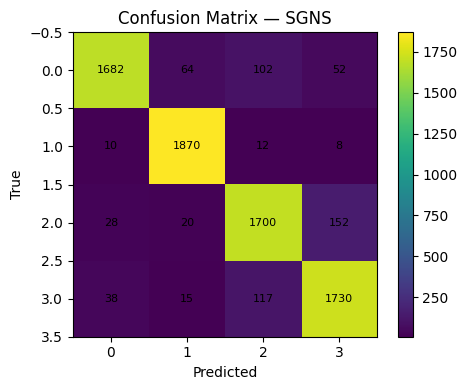

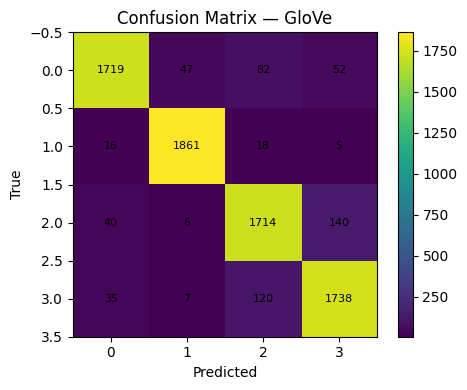

In [15]:
def plot_confmat(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=200)

final_rows = []
for key in ["SGNS", "GloVe"]:
    model = best_models[key]["model"]
    probs = model.predict(x_test, batch_size=256, verbose=0)
    y_pred = probs.argmax(axis=1)

    acc = (y_pred == y_test).mean()
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    final_rows.append({"embedding": key, "test_acc": float(acc), "test_macro_f1": float(macro_f1)})

    plot_confmat(y_test, y_pred, f"Confusion Matrix — {key}", OUT_T1/"plots"/f"confmat_{key}.png")

    print("\n=== ", key, " ===")
    print(classification_report(y_test, y_pred, digits=4))

pd.DataFrame(final_rows).to_csv(OUT_T1/"final_comparison.csv", index=False)
pd.DataFrame(final_rows)

plt.show()

## Task 2 — Identify the Odd Tragedy
We represent each play using two stylometric feature families:
1) character n-gram TF-IDF (3–5 grams) to capture orthographic and morphological habits robustly,
2) function-word relative frequencies (topic-robust cues widely used in stylometry).

We then apply (i) hierarchical clustering and (ii) outlier scoring, and quantify uncertainty with a chunking + bootstrap stability analysis.

In [16]:
def load_plays(path: Path) -> dict[str, str]:
    text = path.read_text(encoding="utf-8", errors="ignore")
    starts = [(m.group(1), m.end()) for m in re.finditer(r"###(\d{2})###", text)]
    ends = [m.start() for m in re.finditer(r"######", text)]
    assert len(starts) == 10 and len(ends) == 10, (len(starts), len(ends))
    plays = {}
    for i, (nn, s_end) in enumerate(starts):
        seg = text[s_end:ends[i]].strip()
        plays[nn] = seg
    return plays

plays = load_plays(FRENCH_PATH)
play_ids = sorted(plays.keys())
docs = [plays[i] for i in play_ids]

print("Plays:", play_ids)
print("Lines per play:", {i: len(plays[i].splitlines()) for i in play_ids})

Plays: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
Lines per play: {'01': 1976, '02': 2130, '03': 1838, '04': 2098, '05': 1964, '06': 1671, '07': 2166, '08': 2091, '09': 2282, '10': 1941}


In [17]:
def normalize_for_char(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ'\s-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def tokenize_words(text: str) -> list[str]:
    t = text.lower()
    t = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ'\s-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t.split()

FRENCH_FUNCTION_WORDS = sorted(set("""
alors au aucuns aussi autre avant avec avoir car ce cela ces ceux chaque ci comme comment dans de des du
elle elles en encore est et eu fait font hors ici il ils je la le les leur lui là ma mais me même mes moi moins mon ne nos notre nous
on ou où par parce pas peut peu plus pour pourquoi quand que quel quelle quelles quels qui sa sans se ses si son sont sous sur ta te tel
toute tout tous très tu un une vos votre vous y à être c' d' j' l' m' n' s' t' qu'
""".split()))

def function_word_features(doc: str, function_words: list[str]) -> np.ndarray:
    toks = tokenize_words(doc)
    total = max(1, len(toks))
    counts = {w: 0 for w in function_words}
    for tok in toks:
        if tok in counts:
            counts[tok] += 1
    return np.array([counts[w] / total for w in function_words], dtype=np.float64)

# Play-level vectors
char_vec = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2, max_df=0.9, sublinear_tf=True, norm="l2")
X_char = char_vec.fit_transform([normalize_for_char(d) for d in docs])

X_fw = np.vstack([function_word_features(d, FRENCH_FUNCTION_WORDS) for d in docs])
scaler = StandardScaler()
X_fw_z = scaler.fit_transform(X_fw)

svd = TruncatedSVD(n_components=100, random_state=SEED)
X_char_red = svd.fit_transform(X_char)

X = np.hstack([X_char_red, X_fw_z])

# PCA 2D
pca2 = PCA(n_components=2, random_state=SEED)
X2 = pca2.fit_transform(X)

# Clustering
dist = pdist(X, metric="cosine")
Z = linkage(dist, method="average")

# Outlier
lof = LocalOutlierFactor(n_neighbors=3)
lof_pred = lof.fit_predict(X)
lof_score = -lof.negative_outlier_factor_

iso = IsolationForest(random_state=SEED, n_estimators=500, contamination="auto")
iso.fit(X)
iso_score = -iso.score_samples(X)

play_level = pd.DataFrame({
    "play": play_ids,
    "lof_outlier_score": lof_score,
    "iso_outlier_score": iso_score,
    "pca_x": X2[:,0],
    "pca_y": X2[:,1],
}).sort_values("iso_outlier_score", ascending=False)

play_level.to_csv(OUT_T2/"task2_play_level_outliers.csv", index=False)
play_level

,play,lof_outlier_score,iso_outlier_score,pca_x,pca_y
6,07,1.359678,0.545331,9.544439,9.828661
5,06,1.189565,0.518265,-10.103921,2.021855
8,09,1.188761,0.502312,-8.570078,4.255420
2,03,1.040596,0.492800,4.345720,-6.829190
1,02,1.015427,0.474243,0.251423,-3.015987
9,10,0.979058,0.469340,-1.882123,-0.769923
4,05,1.030890,0.465216,3.501985,-1.084183
3,04,0.994007,0.461639,0.029204,-1.538250
7,08,1.015191,0.446575,1.223748,-1.555481
0,01,0.998711,0.446359,1.659604,-1.312922


,play,bootstrap_flag_rate
5,06,0.516667
6,07,0.296667
2,03,0.090000
8,09,0.030000
9,10,0.016667
4,05,0.016667
7,08,0.010000
0,01,0.010000
1,02,0.006667
3,04,0.006667


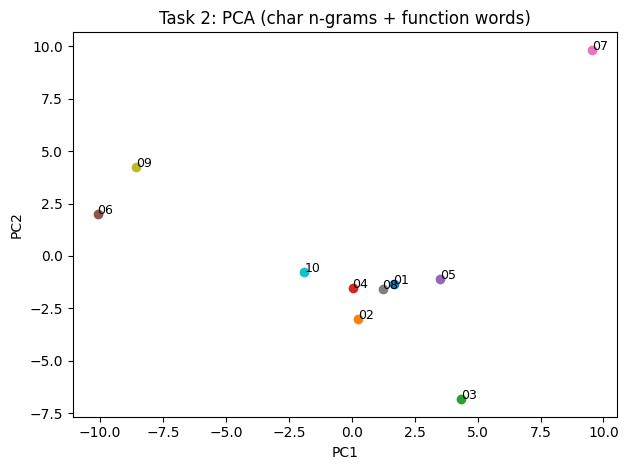

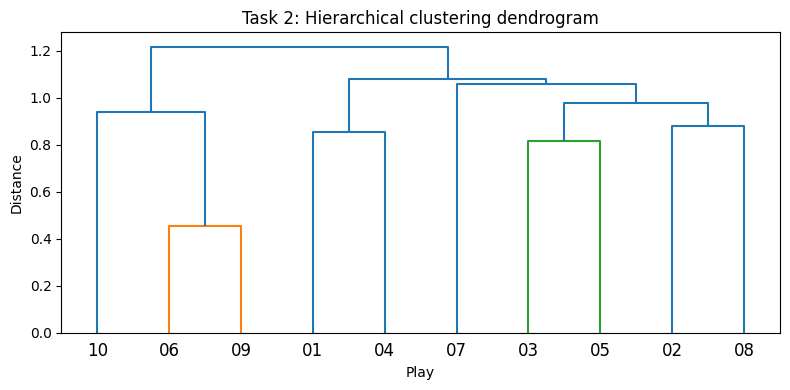

In [18]:
# PCA scatter
plt.figure()
for i, pid in enumerate(play_ids):
    plt.scatter(X2[i,0], X2[i,1])
    plt.text(X2[i,0], X2[i,1], pid, fontsize=9)
plt.title("Task 2: PCA (char n-grams + function words)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUT_T2/"plots"/"task2_pca_scatter.png", dpi=200)

# Dendrogram
plt.figure(figsize=(8,4))
dendrogram(Z, labels=play_ids)
plt.title("Task 2: Hierarchical clustering dendrogram")
plt.xlabel("Play"); plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(OUT_T2/"plots"/"task2_dendrogram.png", dpi=200)

# Bootstrap stability with chunking
def chunk_by_lines(text: str, chunk_lines: int = 200) -> list[str]:
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    return ["\n".join(lines[i:i+chunk_lines]) for i in range(0, len(lines), chunk_lines) if len(lines[i:i+chunk_lines]) > 0]

chunk_lines = 200
chunk_docs, chunk_play = [], []
for pid in play_ids:
    for ch in chunk_by_lines(plays[pid], chunk_lines=chunk_lines):
        chunk_docs.append(ch)
        chunk_play.append(pid)

Xc_char = char_vec.fit_transform([normalize_for_char(d) for d in chunk_docs])
Xc_fw = np.vstack([function_word_features(d, FRENCH_FUNCTION_WORDS) for d in chunk_docs])
Xc_fw_z = scaler.fit_transform(Xc_fw)
Xc_char_red = svd.fit_transform(Xc_char)
Xc = np.hstack([Xc_char_red, Xc_fw_z])

chunk_play_arr = np.array(chunk_play)
idx_by_play = {pid: np.where(chunk_play_arr == pid)[0] for pid in play_ids}

B = 300
rng = np.random.default_rng(SEED)
flag_counts = {pid: 0 for pid in play_ids}

for b in range(B):
    boot_vecs = []
    boot_pids = []
    for pid in play_ids:
        idxs = idx_by_play[pid]
        sampled = rng.choice(idxs, size=len(idxs), replace=True)
        boot_vecs.append(Xc[sampled].mean(axis=0))
        boot_pids.append(pid)

    Xb = np.vstack(boot_vecs)
    iso_b = IsolationForest(random_state=SEED+b, n_estimators=300, contamination="auto")
    iso_b.fit(Xb)
    scores = -iso_b.score_samples(Xb)
    odd = boot_pids[int(np.argmax(scores))]
    flag_counts[odd] += 1

stability = pd.DataFrame({
    "play": play_ids,
    "bootstrap_flag_rate": [flag_counts[p]/B for p in play_ids]
}).sort_values("bootstrap_flag_rate", ascending=False)

stability.to_csv(OUT_T2/"task2_bootstrap_stability.csv", index=False)
stability

# Appendix — Code and Reproducibility Notes
All experiments were run with fixed random seeds (Python, NumPy, TensorFlow). File paths and outputs are saved under `outputs/task1` and `outputs/task2`.